In [2]:
from spatialdata_io import xenium
import spatialdata as sd

/usr/lib/python3.12/importlib/__init__.py:90: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  return _bootstrap._gcd_import(name[level:], package, level)


## Load the Xenium output to a SpatialData object

**FFPE Human Prostate Adenocarcinoma with 5K Human Pan Tissue and Pathways Panel**

https://www.10xgenomics.com/datasets/xenium-prime-ffpe-human-prostate

In [ ]:
xenium_path = "/media/augusta/Xenium5K"
sdata = xenium(xenium_path)

In [5]:
# Save the spatialdata object
sdata.write('data/Xenium5K_human_prostate.zarr')

INFO     The Zarr backing store has been changed from None the new file path: data/Xenium5K_human_prostate.zarr    


INFO     Rasterizing image for faster rendering.                                                                   
INFO     Your image has 4 channels. Sampling categorical colors and using multichannel strategy 'stack' to render. 


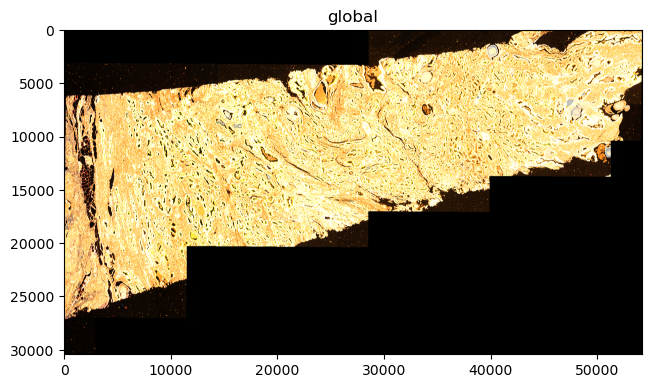

In [22]:
import spatialdata_plot
sdata.pl.render_images().pl.show()

In [4]:
sdata = sd.read_zarr('/content/drive/MyDrive/Courses/DDLS_course/Final_Project/clearCNV/datasets/Xenium5K_human_prostate.zarr')

/usr/local/lib/python3.12/dist-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


/usr/local/lib/python3.12/dist-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/usr/local/lib/python3.12/dist-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/usr/local/lib/python3.12/dist-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/usr/local/lib/python3.12/dist-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/usr/local/lib/python3.12/dist-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning

In [5]:
sdata

SpatialData object, with associated Zarr store: /content/drive/MyDrive/Courses/DDLS_course/Final_Project/clearCNV/datasets/Xenium5K_human_prostate.zarr
├── Images
│     └── 'morphology_focus': DataTree[cyx] (4, 30420, 54160), (4, 15210, 27080), (4, 7605, 13540), (4, 3802, 6770), (4, 1901, 3385)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (30420, 54160), (15210, 27080), (7605, 13540), (3802, 6770), (1901, 3385)
│     └── 'nucleus_labels': DataTree[yx] (30420, 54160), (15210, 27080), (7605, 13540), (3802, 6770), (1901, 3385)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (193000, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (193000, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (184853, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (193000, 5006)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_l

In [6]:
adata = sdata.table
adata

/tmp/ipython-input-1089043534.py:1: DeprecationWarning: Table accessor will be deprecated with SpatialData version 0.1, use sdata.tables instead.
  adata = sdata.table


AnnData object with n_obs × n_vars = 193000 × 5006
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

In [8]:
import numpy as np
import scanpy as sc

# Set random seed for reproducibility (optional)
np.random.seed(42)

# Determine how many cells to keep (5%)
n_cells = int(adata.n_obs * 0.05)

# Randomly choose indices
selected_idx = np.random.choice(adata.n_obs, n_cells, replace=False)

# Subset the AnnData object
adata_subset = adata[selected_idx, :].copy()

In [9]:
adata_subset.write('/content/drive/MyDrive/Courses/DDLS_course/Final_Project/clearCNV/datasets/Xenium5K_human_prostate_subset.h5ad')